## Problem Statement
Predict the price of the Uber ride from a given pickup point to the agreed drop-off
location. Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement linear regression and random forest regression models.
Evaluate the models and compare the irrespective scores like R2, RMSE, etc.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [26]:
path = "./dataset/uber.csv"
df = pd.read_csv(path)

In [27]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [28]:
df.drop(["Unnamed: 0","key"], axis=1, inplace=True)

In [29]:
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [30]:
df.dropna(inplace=True)

Haversine Formula

In [31]:
def getDist(lat1, lat2, lon1, lon2):
    R=6371
    lat1, lat2, lon1, lon2 = map(math.radians, [lat1, lat2, lon1, lon2])

    dlat = lat2-lat1
    dlon = lon2-lon1
    # sign does not matter as we are taking sin^2 
    a = (math.sin(dlat/2)**2) + (math.cos(lat1)*math.cos(lat2)*(math.sin(dlon/2)**2))
    c = 2*math.asin(math.sqrt(a))
    return R*c

In [32]:
df["dist"] = df.apply(lambda row:getDist(row["pickup_latitude"], row["dropoff_latitude"], row["pickup_longitude"], row["dropoff_longitude"]), axis=1)

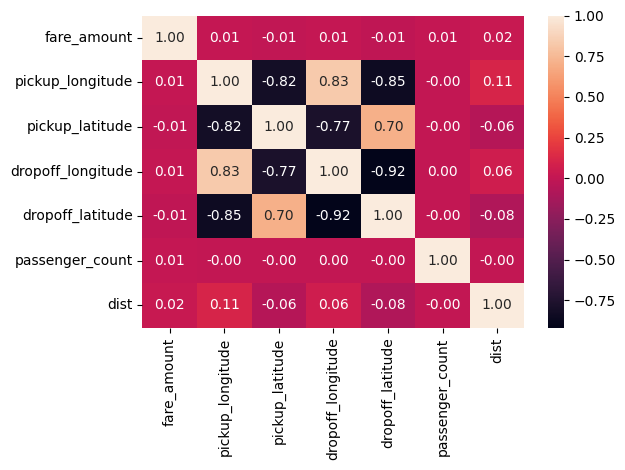

In [33]:
corr_map = df.corr("pearson", numeric_only=True)
sns.heatmap(corr_map, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

<Axes: ylabel='fare_amount'>

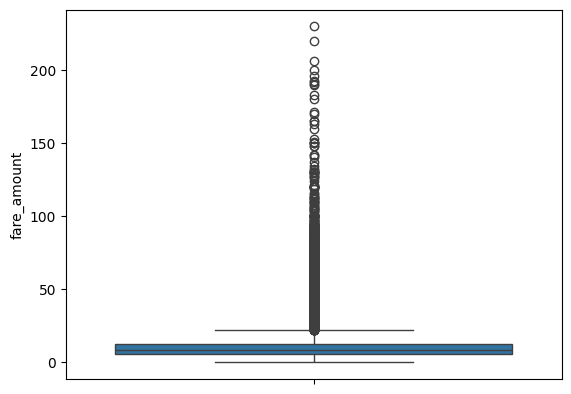

In [36]:
sns.boxplot(df["fare_amount"])

In [35]:
df= df[(df["fare_amount"]>0) & (df["fare_amount"]<250)]

In [37]:
X = df[["dist"]]
Y = df["fare_amount"]

In [38]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=12, shuffle=True, test_size=0.3)

In [39]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

In [40]:
model = lr_model.fit(x_train, y_train)

In [41]:
y_pred = model.predict(x_test)

In [43]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
print(f"""
MSE={root_mean_squared_error(y_test, y_pred)**2}
RMSE={root_mean_squared_error(y_test, y_pred)}
MAE={mean_absolute_error(y_test, y_pred)}
R2_Score={r2_score(y_test, y_pred)}
""")


MSE=95.19450357612037
RMSE=9.756767065791843
MAE=6.025508432375512
R2_Score=0.0005629895187577727



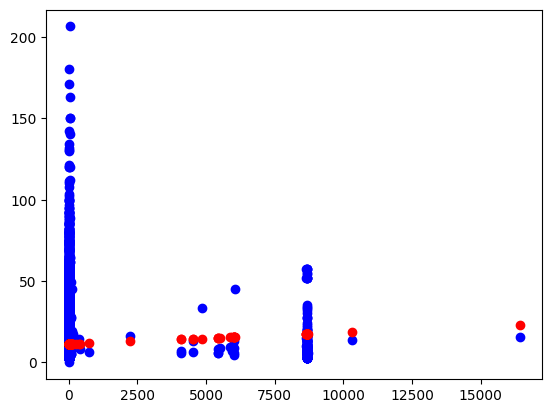

In [44]:
plt.scatter(x_test, y_test, color="blue")
plt.scatter(x_test, y_pred, color="red")
plt.show()

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(max_depth=10)
model1 = rf_model.fit(x_train, y_train)

In [46]:
y_pred = model1.predict(x_test)

In [47]:
print(f"""
RMSE={root_mean_squared_error(y_test, y_pred)}
MSE={root_mean_squared_error(y_test, y_pred)**2}
MAE={mean_absolute_error(y_test, y_pred)}
R2 Score={r2_score(y_test, y_pred)}
""")


RMSE=4.885119595607889
MSE=23.864393463392183
MAE=2.463320458791754
R2 Score=0.7494502606347555



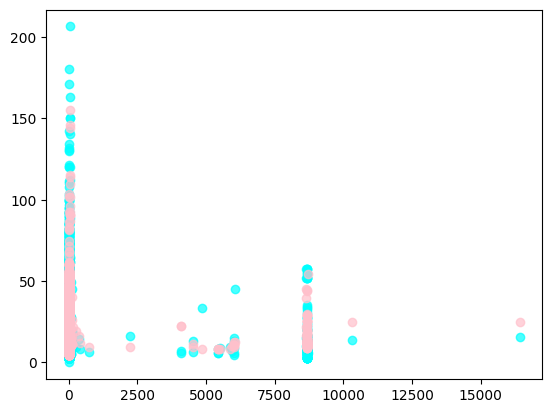

In [48]:
plt.scatter(x_test, y_test, color="cyan", alpha=0.7)
plt.scatter(x_test, y_pred, color="pink", alpha=0.7)
plt.show()